In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [14]:
df=pd.read_csv('cardekho_imputated.csv')

In [15]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [17]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [18]:
df.drop("Unnamed: 0",axis=1,inplace=True)
df.drop("car_name",axis=1,inplace=True)
df.drop("brand",axis=1,inplace=True)
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


<BarContainer object of 15411 artists>

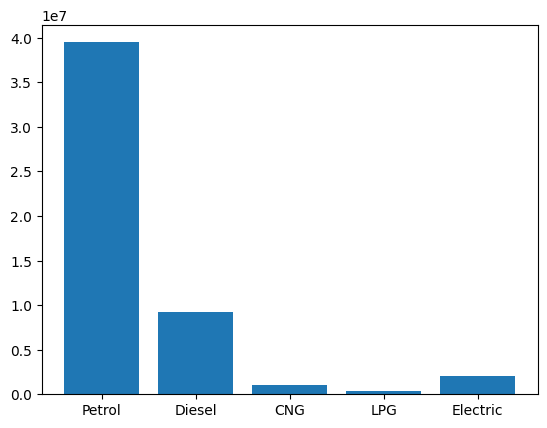

In [12]:
plt.bar(df["fuel_type"],df["selling_price"])

In [32]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model              15411 non-null  object 
 1   vehicle_age        15411 non-null  int64  
 2   km_driven          15411 non-null  int64  
 3   seller_type        15411 non-null  object 
 4   fuel_type          15411 non-null  object 
 5   transmission_type  15411 non-null  object 
 6   mileage            15411 non-null  float64
 7   engine             15411 non-null  int64  
 8   max_power          15411 non-null  float64
 9   seats              15411 non-null  int64  
 10  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 1.3+ MB


In [21]:
le=LabelEncoder()

In [23]:
df["model"]=le.fit_transform(df["model"])
df["fuel_type"]=le.fit_transform(df["fuel_type"])
df["seller_type"]=le.fit_transform(df["seller_type"])
df["transmission_type"]=le.fit_transform(df["transmission_type"])


In [24]:
df.describe()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,62.197391,6.036338,5.561648e+04,0.392252,2.474272,0.793265,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,36.322097,3.013291,5.161855e+04,0.510743,1.523609,0.404977,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,0.000000,0.000000,0.000000,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,26.000000,4.000000,3.000000e+04,0.000000,1.000000,1.000000,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,62.000000,6.000000,5.000000e+04,0.000000,1.000000,1.000000,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,92.000000,8.000000,7.000000e+04,1.000000,4.000000,1.000000,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,119.000000,29.000000,3.800000e+06,2.000000,4.000000,1.000000,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [25]:
df.corr()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
model,1.000000,0.033645,0.025116,0.037883,-0.020672,0.154569,0.001098,-0.080132,-0.104738,0.019894,-0.110702
vehicle_age,0.033645,1.000000,0.333891,-0.056234,-0.007613,0.080711,-0.257394,0.098965,0.005208,0.030791,-0.241851
km_driven,0.025116,0.333891,1.000000,0.036078,-0.245421,0.073501,-0.105239,0.192885,0.044421,0.192830,-0.080030
seller_type,0.037883,-0.056234,0.036078,1.000000,0.046451,0.197564,0.082295,-0.120694,-0.184449,0.039560,-0.137198
fuel_type,-0.020672,-0.007613,-0.245421,0.046451,1.000000,0.005156,-0.155834,-0.447268,-0.258257,-0.329337,-0.217803
transmission_type,0.154569,0.080711,0.073501,0.197564,0.005156,1.000000,0.282738,-0.348607,-0.539448,0.058527,-0.459394
mileage,0.001098,-0.257394,-0.105239,0.082295,-0.155834,0.282738,1.000000,-0.632987,-0.533128,-0.440280,-0.305549
engine,-0.080132,0.098965,0.192885,-0.120694,-0.447268,-0.348607,-0.632987,1.000000,0.807368,0.551236,0.585844
max_power,-0.104738,0.005208,0.044421,-0.184449,-0.258257,-0.539448,-0.533128,0.807368,1.000000,0.172257,0.750236
seats,0.019894,0.030791,0.192830,0.039560,-0.329337,0.058527,-0.440280,0.551236,0.172257,1.000000,0.115033


In [26]:
X=df.drop("selling_price",axis=1)
y=df["selling_price"]

In [27]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [58]:
model=RandomForestRegressor(n_estimators=100, min_samples_split=5, max_features=3, max_depth=20, 
                                                     n_jobs=-1)

In [59]:
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [60]:
y_pred=model.predict(X_test)

In [61]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.940930808000203
98222.86977327865
44466212116.00364
